---
title: Non-stationary GEV — a mechanistic ODE
subtitle: A forced energy-balance trajectory for the warming location
short_title: Non-stationary (ODE)
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-09
keywords:
  - non-stationary extremes
  - GEV
  - energy balance model
  - differential equations
  - diffrax
  - NUTS
abstract: |
  The parametric notebook let the GEV location follow a straight line. A line is
  the strongest possible assumption about the *shape* of a trend: it cannot bend,
  lag, or saturate, and it extrapolates without limit. Here we replace it with a
  **mechanistic ordinary differential equation** — a one-box energy-balance model
  in which the location relaxes toward a forced equilibrium with a physical
  response time $\tau$. The trajectory is integrated with `diffrax` *inside* the
  NumPyro model and inferred end-to-end by NUTS. The result is a grey-box that
  sits between the rigid line of [](10_nonstationary_parametric.ipynb) and the
  free Gaussian process of [](12_nonstationary_gp.ipynb): few, physically
  interpretable parameters, but a trajectory whose curvature the data can shape.
---

# Non-stationary extremes: a mechanistic ODE

In [](10_nonstationary_parametric.ipynb) the GEV location drifted along a line,
$\mu(t)=\mu_0+\mu_1 z(t)$. That worked — WAIC preferred it, the warming was clear
— but the linear form is an assumption *imposed* on the trend, not learned. The
real climate does not warm along a ruler: forcing accumulates, and the surface
temperature **lags** it with a memory of years to decades, so the warming curve
can be concave, can accelerate, can saturate.

This notebook encodes that mechanism directly. We model the location as

$$\mu(t) = \mu_0 + T(t),$$

where $T(t)$ — a temperature *anomaly* — is the solution of a differential
equation, not a fixed algebraic curve. We integrate that ODE with
[`diffrax`](https://github.com/patrick-kidger/diffrax) inside the probabilistic
model, so its physical parameters are inferred jointly with the GEV scale and
shape by the same NUTS sampler we have used throughout.

## Background

### A one-box energy-balance model

The simplest climate model is a single heat reservoir relaxing toward the
equilibrium set by a radiative forcing $F(t)$:

```{math}
:label: eq:ebm
\tau\,\frac{\mathrm{d}T}{\mathrm{d}t} \;=\; \beta\,F(t) \;-\; T(t),
\qquad T(t_0)=0 .
```

Two parameters carry all the physics:

- $\tau$ — the **response time** (years). Small $\tau$: the system tracks the
  forcing almost instantly, so $T$ inherits $F$'s shape. Large $\tau$: the system
  is sluggish, averaging and lagging the forcing into a smoother, flatter curve.
- $\beta$ — the **sensitivity** (°C). With $F$ normalized to end at $1$, $\beta$
  is the equilibrium warming the system is heading toward; the *realized* warming
  over a finite record is always less, because of the lag.

This is a genuine *grey box*: far more structured than a free curve (only two
knobs, both interpretable), yet — unlike the line — able to bend. The line of the
previous notebook is in fact the $\tau\to\infty$, slowly-forced limit of
{eq}`eq:ebm`.

### A forcing proxy

The honest input would be an observed effective-forcing series, but to keep every
notebook offline we prescribe a **stylized** anthropogenic ramp that grows faster
in recent decades (as greenhouse forcing has),

```{math}
:label: eq:forcing
F(t) = \frac{e^{\alpha u(t)}-1}{e^{\alpha}-1},
\qquad u(t)=\frac{t-t_0}{t_1-t_0}\in[0,1],
```

fixed and known (we use a mild acceleration $\alpha=2$). Swapping in a real
forcing time series is a one-line change to `forcing(t)` — the inference machinery
is identical.

### What the data can and cannot pin down

With ~115 noisy maxima we should expect the *amount* of warming ($\beta$, and the
realized end-to-end shift) to be well constrained, but the *mechanism* — the
response time $\tau$ — only weakly so: many $(\beta,\tau)$ pairs trace nearly the
same century-long curve. We will see exactly that, and it is the right lesson
about fitting dynamics to short records.

## Setup

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
jax.config.update("jax_enable_x64", True)        # GEV + ODE want float64

import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
import seaborn as sns

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from diffrax import ODETerm, Tsit5, diffeqsolve, SaveAt, ConstantStepSize

from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_log_prob, gev_survival

from spatial_extremes import data, viz

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

In [3]:
# Same long station as the parametric notebook: Albacete, 1901-2025.
years, maxima, meta = data.load_single_station()
place = meta["name"]
y_np = np.asarray(maxima, float)
yr = np.asarray(years, int)
m = y_np.size
y = jnp.asarray(y_np)
y_mean, y_std = float(y.mean()), float(y.std())
t0, t1 = float(yr.min()), float(yr.max())
ts = jnp.asarray(yr, float)          # observation times for the ODE solve
ALPHA = 2.0                          # forcing acceleration (fixed)

print("source:", "REAL CDS" if meta["is_real"] else "synthetic")
print(f"{place} — id {meta['station_id']}, {m} annual maxima, {yr.min()}-{yr.max()}")

source: REAL CDS
Albacete — id SP000008280, 115 annual maxima, 1901-2025


### The forcing and the solver

`forcing(t)` is the fixed proxy {eq}`eq:forcing`; `integrate(beta, tau, tq)`
solves the energy-balance ODE {eq}`eq:ebm` and returns $T$ at the requested times.
We use a **fixed-step** solver (`ConstantStepSize`, ½-year steps): the ODE is a
simple non-stiff relaxation, and a constant step keeps the step count bounded and
differentiable — essential when NUTS probes tiny $\tau$, where an *adaptive*
controller would refine to a halt.

In [4]:
def forcing(t):
    u = (t - t0) / (t1 - t0)
    return (jnp.exp(ALPHA * u) - 1.0) / (jnp.exp(ALPHA) - 1.0)

def integrate(beta, tau, tq):
    def vf(t, T, args):
        return (beta * forcing(t) - T) / tau
    sol = diffeqsolve(ODETerm(vf), Tsit5(), t0=t0, t1=t1, dt0=0.5, y0=0.0,
                      saveat=SaveAt(ts=tq), stepsize_controller=ConstantStepSize(),
                      max_steps=2000)
    return sol.ys

# sanity: the solve is differentiable end-to-end (needed for NUTS gradients)
g = jax.grad(lambda p: integrate(p[0], p[1], ts)[-1])(jnp.array([2.0, 20.0]))
print("dT_end/d(beta,tau) =", [float(v) for v in g])

dT_end/d(beta,tau) = [0.7179999997438439, -0.02127391761606827]


Before fitting, look at what the model can *say*. For a fixed forcing, the
response time $\tau$ alone reshapes the trajectory — fast systems (small $\tau$)
inherit the forcing's acceleration, sluggish ones (large $\tau$) lag into a
straighter, flatter curve. This is the flexibility the data will exploit.

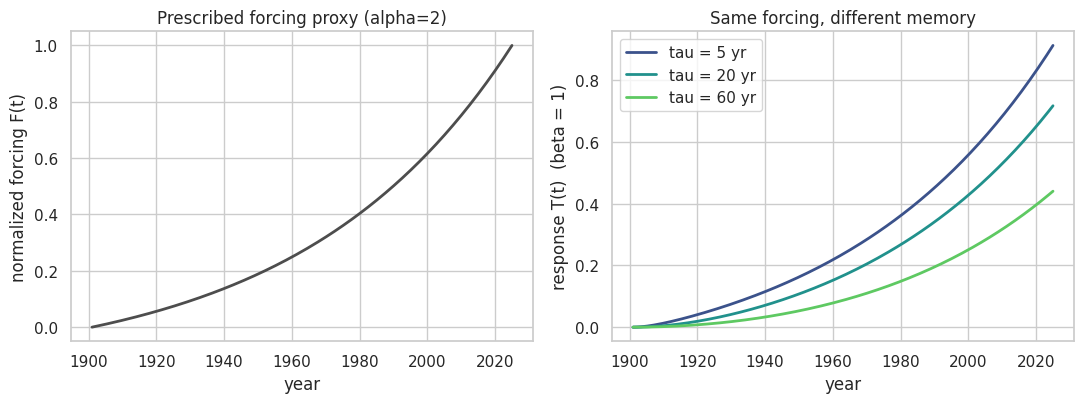

In [5]:
tgrid = jnp.linspace(t0, t1, 200)
fig, (axF, axT) = plt.subplots(1, 2, figsize=(11, 4.2))
axF.plot(np.asarray(tgrid), np.asarray(forcing(tgrid)), color="0.3", lw=2)
axF.set(xlabel="year", ylabel="normalized forcing F(t)",
        title=f"Prescribed forcing proxy (alpha={ALPHA:g})")
for tau, c in zip((5.0, 20.0, 60.0), sns.color_palette("viridis", 3)):
    axT.plot(np.asarray(tgrid), np.asarray(integrate(1.0, tau, tgrid)),
             color=c, lw=2, label=f"tau = {tau:g} yr")
axT.set(xlabel="year", ylabel="response T(t)  (beta = 1)",
        title="Same forcing, different memory")
axT.legend()
fig.tight_layout()
plt.show()

## The model

The probabilistic model is the GEV likelihood with a location that **is the ODE
solution**. Inside `numpyro` we sample the physical parameters, call `integrate`
to get $T$ at every observation year, and feed $\mu(t)=\mu_0+T(t)$ to the GEV.
NUTS differentiates straight through the solver.

In [6]:
def gev_ode(obs):
    mu0 = numpyro.sample("mu0", ndist.Normal(y_mean, 5.0))     # baseline location
    beta = numpyro.sample("beta", ndist.Normal(0.0, 3.0))      # warming amplitude (degC)
    tau = numpyro.sample("tau", ndist.LogNormal(np.log(20.0), 0.8))  # response time (yr)
    log_sigma = numpyro.sample("log_sigma", ndist.Normal(np.log(y_std), 0.5))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    T = integrate(beta, tau, ts)                               # anomaly at each year
    numpyro.sample("obs", GEV(loc=mu0 + T, scale=jnp.exp(log_sigma),
                              concentration=xi), obs=obs)

mcmc = MCMC(NUTS(gev_ode, target_accept_prob=0.95, init_strategy=init_to_median),
            num_warmup=1000, num_samples=1000, num_chains=2,
            chain_method="sequential", progress_bar=False)
mcmc.run(jr.PRNGKey(0), y)
mcmc.print_summary()
post = mcmc.get_samples()
print(f"divergences: {int(mcmc.get_extra_fields()['diverging'].sum())}")


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       beta      2.59      0.98      2.46      1.05      4.16    911.86      1.00
  log_sigma      0.38      0.07      0.38      0.27      0.50   1436.14      1.00
        mu0     37.52      0.22     37.51     37.19     37.92   1214.26      1.00
        tau     27.91     21.65     22.28      2.86     54.03    978.98      1.00
         xi     -0.09      0.05     -0.09     -0.17     -0.02   1133.18      1.00

Number of divergences: 1
divergences: 1


### Hand-off: cache this posterior

Notebook 12 compares its GP trend against this ODE fit — same station, same
data, same model, so refitting it there would be six minutes of arithmetic we
have already done. Cache the draws instead; notebook 12 loads them and checks
the record really is identical before trusting them.


In [7]:
from spatial_extremes import results

path = results.save_fit(
    "ode_gev_albacete",
    source="notebooks/04_nonstationary/11_nonstationary_ode.ipynb",
    is_real=meta["is_real"],
    years=yr,                       # guard: the consumer checks these match
    y=y_np,
    mu0=np.asarray(post["mu0"]),    # location at t0 = 1901 (T(t0) = 0)
    beta=np.asarray(post["beta"]),
    tau=np.asarray(post["tau"]),
    log_sigma=np.asarray(post["log_sigma"]),
    xi=np.asarray(post["xi"]),
)
print("cached ->", path)

cached -> /home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/cds_insitu/spatial_extremes/results/ode_gev_albacete.npz


### Reading the physics

$\beta$ is the equilibrium warming the climate is heading toward; the **realized**
warming over the record, $T(t_1)-T(t_0)$, is what actually happened and is the
quantity to compare with the parametric notebook's $+1.4$°C. The response time
$\tau$ is far less certain — its posterior is broad and right-skewed, the
signature of a mechanism only weakly identified by a century of noisy maxima.

In [8]:
def ci(a): return np.quantile(a, [0.025, 0.5, 0.975])
beta_s = np.asarray(post["beta"]); tau_s = np.asarray(post["tau"])
# realized warming over the record for each draw
sub = jr.choice(jr.PRNGKey(1), beta_s.size, (600,), replace=False)
T_ends = np.asarray(jax.vmap(lambda b, ta: integrate(b, ta, jnp.array([t0, t1]))
                             )(post["beta"][sub], post["tau"][sub]))
realized = T_ends[:, 1] - T_ends[:, 0]
blo, bmd, bhi = ci(beta_s); rlo, rmd, rhi = ci(realized)
tlo, tmd, thi = ci(tau_s)
print(f"beta  (equilibrium warming) : {bmd:.2f} degC   (95% CI {blo:.2f}, {bhi:.2f})")
print(f"realized warming {yr.min()}-{yr.max()}: {rmd:.2f} degC   (95% CI {rlo:.2f}, {rhi:.2f})")
print(f"tau   (response time)       : {tmd:.0f} yr     (95% CI {tlo:.0f}, {thi:.0f})")
print(f"P(beta > 0 | data) = {float((beta_s > 0).mean()):.3f}")

beta  (equilibrium warming) : 2.46 degC   (95% CI 1.03, 4.85)
realized warming 1901-2025: 1.66 degC   (95% CI 0.71, 2.58)
tau   (response time)       : 22 yr     (95% CI 5, 85)
P(beta > 0 | data) = 0.998


The joint posterior makes the weak identifiability concrete: $\beta$ and
$\tau$ trade off along a ridge — a stronger, slower response looks much like a
weaker, faster one over 124 years — while the realized warming (the integral the
data actually see) is pinned far more tightly.

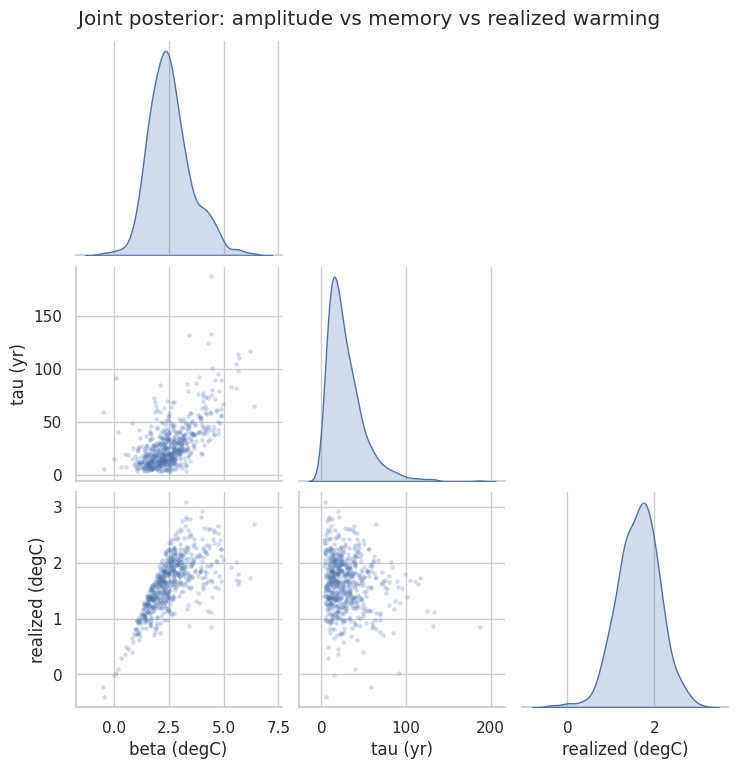

In [9]:
draws = pd.DataFrame({"beta (degC)": beta_s[sub], "tau (yr)": tau_s[sub],
                      "realized (degC)": realized})
g = sns.pairplot(draws, corner=True, diag_kind="kde",
                 plot_kws=dict(s=8, alpha=0.25, edgecolor=None),
                 diag_kws=dict(fill=True))
g.figure.suptitle("Joint posterior: amplitude vs memory vs realized warming", y=1.02)
plt.show()

## The fitted trajectory — and the line it replaces

Now the payoff of a mechanistic trend: a **curved** warming trajectory with
uncertainty. We overlay the posterior $\mu(t)=\mu_0+T(t)$ on the maxima, and — for
a direct contrast — refit the linear model of
[](10_nonstationary_parametric.ipynb) and draw its straight $\mu(t)$ through the
same data. The ODE bends where the line cannot.

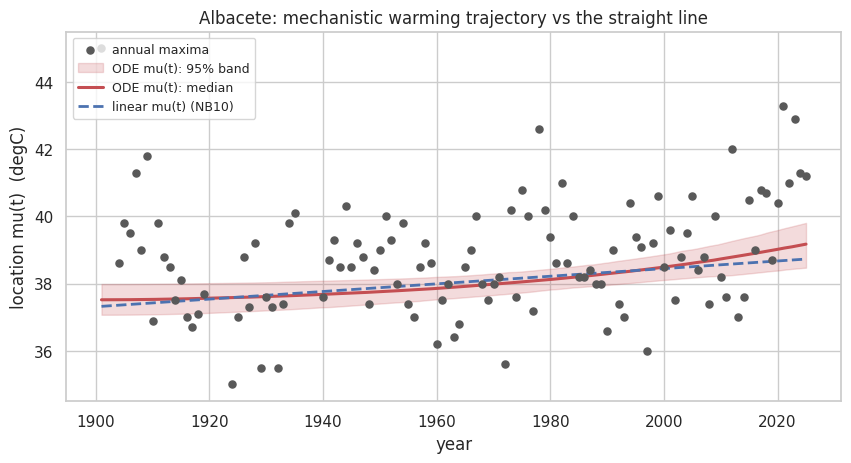

In [10]:
# posterior trajectory band on a dense grid
mu_draws = (post["mu0"][sub][:, None]
            + jax.vmap(lambda b, ta: integrate(b, ta, tgrid))(
                post["beta"][sub], post["tau"][sub]))
mu_draws = np.asarray(mu_draws)
mu_med, mu_lo, mu_hi = (np.quantile(mu_draws, q, 0) for q in (0.5, 0.025, 0.975))

# quick refit of the linear-location model for comparison
z_np = (yr - yr.mean()) / yr.std()
z = jnp.asarray(z_np)
def gev_lin(obs, zc):
    a = numpyro.sample("a", ndist.Normal(y_mean, 5.0))
    b = numpyro.sample("b", ndist.Normal(0.0, 2.0))
    ls = numpyro.sample("ls", ndist.Normal(np.log(y_std), 0.5))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample("obs", GEV(loc=a + b * zc, scale=jnp.exp(ls),
                              concentration=xi), obs=obs)
lin = MCMC(NUTS(gev_lin, target_accept_prob=0.99, init_strategy=init_to_median),
           num_warmup=1000, num_samples=1000, num_chains=2,
           chain_method="vectorized", progress_bar=False)
lin.run(jr.PRNGKey(2), y, z)
plin = lin.get_samples()
zg = (np.asarray(tgrid) - yr.mean()) / yr.std()
mu_lin = np.median(plin["a"])[None] + np.median(plin["b"]) * zg

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.scatter(yr, y_np, color="0.35", s=26, zorder=4, label="annual maxima")
ax.fill_between(np.asarray(tgrid), mu_lo, mu_hi, color="#C44E52", alpha=0.20,
                label="ODE mu(t): 95% band")
ax.plot(np.asarray(tgrid), mu_med, color="#C44E52", lw=2.2, label="ODE mu(t): median")
ax.plot(np.asarray(tgrid), mu_lin, color="#4C72B0", lw=2, ls="--",
        label="linear mu(t) (NB10)")
ax.set(xlabel="year", ylabel="location mu(t)  (degC)",
       title=f"{place}: mechanistic warming trajectory vs the straight line")
ax.legend(loc="upper left", fontsize=9)
plt.show()

## Does the mechanism earn its keep? WAIC

The ODE has the same parameter count as the linear model (two location knobs:
here $\beta,\tau$; there intercept, slope), so WAIC is a fair contest. We score
the stationary, linear, and ODE models on the same maxima.

In [11]:
def waic(ll):
    S = ll.shape[0]
    lppd = logsumexp(ll, axis=0) - jnp.log(S)
    return float(-2.0 * (lppd.sum() - ll.var(axis=0).sum()))

# stationary baseline (constant location)
def gev_stat(obs):
    mu = numpyro.sample("mu", ndist.Normal(y_mean, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(y_std))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample("obs", GEV(loc=mu, scale=sigma, concentration=xi), obs=obs)
stat = MCMC(NUTS(gev_stat, target_accept_prob=0.99, init_strategy=init_to_median),
            num_warmup=1000, num_samples=1000, num_chains=2,
            chain_method="vectorized", progress_bar=False)
stat.run(jr.PRNGKey(3), y)
ps = stat.get_samples()

ll_stat = gev_log_prob(y[None, :], ps["mu"][:, None], ps["sigma"][:, None],
                       ps["xi"][:, None])
ll_lin = gev_log_prob(y[None, :], plin["a"][:, None] + plin["b"][:, None] * z[None, :],
                      jnp.exp(plin["ls"])[:, None], plin["xi"][:, None])
T_all = jax.vmap(lambda b, ta: integrate(b, ta, ts))(post["beta"], post["tau"])
ll_ode = gev_log_prob(y[None, :], post["mu0"][:, None] + T_all,
                      jnp.exp(post["log_sigma"])[:, None], post["xi"][:, None])
tab = pd.DataFrame({"WAIC": [waic(ll_stat), waic(ll_lin), waic(ll_ode)]},
                   index=["stationary", "linear mu(t)", "ODE mu(t)"])
tab["dWAIC"] = tab["WAIC"] - tab["WAIC"].min()
print(tab.round(2).to_string())

                WAIC  dWAIC
stationary    448.04   9.44
linear mu(t)  442.72   4.12
ODE mu(t)     438.60   0.00


## Time-varying return levels

As in the parametric notebook the return level is now a function of year. We read
{eq}`eq:gev-rl` at the ODE location $\mu(t)=\mu_0+T(t)$ for the first and last
years, and place each observed maximum at *its own* year's climate (its return
period under the fitted GEV for that year), coloured by year — so the cloud rides
the ODE trajectory from the early envelope up to the recent one.

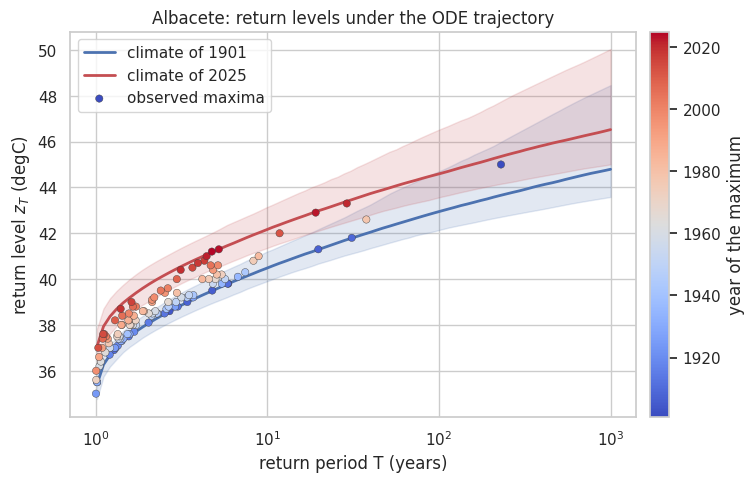

In [12]:
# median-parameter ODE location at each year, and at the two reference years
mu0_m = float(np.median(post["mu0"]))
sig_m = float(np.exp(np.median(post["log_sigma"])))
xi_m = float(np.median(post["xi"]))
beta_m, tau_m = float(np.median(beta_s)), float(np.median(tau_s))
loc_year = mu0_m + np.asarray(integrate(beta_m, tau_m, ts))
loc_first, loc_last = float(loc_year[0]), float(loc_year[-1])

# each maximum at its own-year climate
p_t = np.asarray(gev_survival(y, jnp.asarray(loc_year), sig_m, xi_m))
p_t = np.clip(p_t, 0.5 / m, None)
T_own = 1.0 / p_t
t_lo = max(1.02, float(T_own.min()))
periods = jnp.logspace(np.log10(t_lo), 3, 80)

idx = jr.choice(jr.PRNGKey(5), post["mu0"].size, (600,), replace=False)

def rl_curve_at(tref):
    # each posterior draw's location at year tref = mu0 + T(tref; beta, tau)
    Tref = jax.vmap(lambda b, ta: integrate(b, ta, jnp.array([float(tref)]))[0])(
        post["beta"][idx], post["tau"][idx])
    locs = post["mu0"][idx] + Tref
    sig = jnp.exp(post["log_sigma"])[idx]; xi = post["xi"][idx]
    rl = jax.vmap(lambda i: GEV(loc=locs[i], scale=sig[i], concentration=xi[i])
                  .return_level(periods))(jnp.arange(locs.size))
    return np.asarray(rl)

fig, ax = plt.subplots(figsize=(8.8, 5))
for tref, c, lab in [(t0, "#4C72B0", f"climate of {yr.min()}"),
                     (t1, "#C44E52", f"climate of {yr.max()}")]:
    rl = rl_curve_at(tref)
    med, lo, hi = (np.quantile(rl, q, 0) for q in (0.5, 0.025, 0.975))
    ax.fill_between(np.asarray(periods), lo, hi, color=c, alpha=0.16)
    ax.plot(np.asarray(periods), med, color=c, lw=2, label=lab)
sc = ax.scatter(T_own, y_np, c=yr, cmap="coolwarm", s=28, zorder=6,
                edgecolor="0.25", linewidth=0.3, label="observed maxima")
fig.colorbar(sc, ax=ax, pad=0.02).set_label("year of the maximum")
ax.set_xscale("log")
ax.set(xlabel="return period T (years)", ylabel=r"return level $z_T$ (degC)",
       title=f"{place}: return levels under the ODE trajectory")
ax.legend(loc="upper left")
plt.show()

## Extension: couple the scale to the same state

A clean feature of the grey box is that *one* latent state can drive several GEV
parameters. We let the log-scale share the trajectory, $\log\sigma(t)=s_0+b_\sigma
T(t)$, so the spread of summer maxima rises (or falls) with the same warming
signal — and check whether the data want it.

In [13]:
def gev_ode_sigma(obs):
    mu0 = numpyro.sample("mu0", ndist.Normal(y_mean, 5.0))
    beta = numpyro.sample("beta", ndist.Normal(0.0, 3.0))
    tau = numpyro.sample("tau", ndist.LogNormal(np.log(20.0), 0.8))
    s0 = numpyro.sample("s0", ndist.Normal(np.log(y_std), 0.5))
    b_sig = numpyro.sample("b_sig", ndist.Normal(0.0, 0.3))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    T = integrate(beta, tau, ts)
    numpyro.sample("obs", GEV(loc=mu0 + T, scale=jnp.exp(s0 + b_sig * T),
                              concentration=xi), obs=obs)

mcmc_s = MCMC(NUTS(gev_ode_sigma, target_accept_prob=0.95, init_strategy=init_to_median),
              num_warmup=1000, num_samples=1000, num_chains=2,
              chain_method="sequential", progress_bar=False)
mcmc_s.run(jr.PRNGKey(4), y)
ps2 = mcmc_s.get_samples()
bsig = np.asarray(ps2["b_sig"]); s_lo, s_md, s_hi = ci(bsig)
T_all2 = jax.vmap(lambda b, ta: integrate(b, ta, ts))(ps2["beta"], ps2["tau"])
ll_ode_s = gev_log_prob(y[None, :], ps2["mu0"][:, None] + T_all2,
                        jnp.exp(ps2["s0"][:, None] + ps2["b_sig"][:, None] * T_all2),
                        ps2["xi"][:, None])
print(f"b_sig (scale coupling) = {s_md:+.3f}  (95% CI {s_lo:+.3f}, {s_hi:+.3f})")
print(f"WAIC: ODE mu only {waic(ll_ode):.1f}  |  ODE mu+sigma {waic(ll_ode_s):.1f}")
print("scale coupling " + ("helps" if waic(ll_ode_s) < waic(ll_ode) - 2
      else "is not supported by the data"))

b_sig (scale coupling) = -0.024  (95% CI -0.293, +0.271)
WAIC: ODE mu only 438.6  |  ODE mu+sigma 440.0
scale coupling is not supported by the data


## Recap & where next

We swapped the straight line for a **mechanism**. The GEV location is now the
solution of a forced energy-balance ODE {eq}`eq:ebm`, integrated with `diffrax`
inside the model and inferred by NUTS. The realized warming matches the
parametric fit, but the trajectory can **curve** — and the posterior is candid
about what a century of maxima can support: the warming amplitude is well
determined, the response time $\tau$ much less so.

The grey box buys interpretability and physically-bounded extrapolation at the
price of a *committed* functional form: if the true trend does not look like a
one-box relaxation, the ODE cannot represent it. The final notebook,
[](12_nonstationary_gp.ipynb), goes to the opposite pole — a **Gaussian process**
over time that assumes only smoothness and lets the data draw the warming curve
freely — and puts all three trend models, line, ODE, and GP, on the same axes.